In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks
from preprocessing import *
from solver import solve_sudoku, display_board, is_valid_sudoku

In [2]:
def display_image_grayscale(image, title="Image"):
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_image_color(image, title="Image"):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

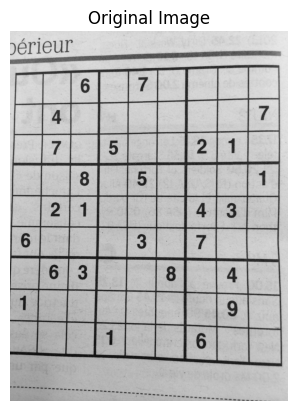

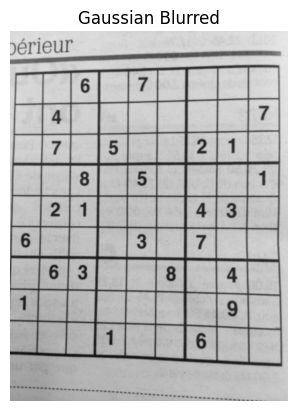

In [3]:
image = cv2.imread("images/image1000.jpg", cv2.IMREAD_GRAYSCALE)
L = 5
box_kernel = np.ones((L, L)) / (L**2)
gaussian_kernel = create_gaussian_kernel(9)

blurred_image = linear_filter(image, box_kernel)
median_filter_image = median_filter(image, L)
gaussian_image = linear_filter(image, gaussian_kernel)

display_image_grayscale(image, "Original Image")
display_image_grayscale(gaussian_image, "Gaussian Blurred")

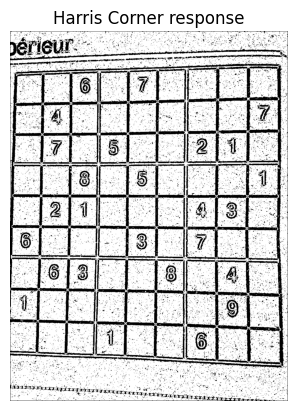

In [4]:
# Compute Harris corner response
response = harris_corners(image)
display_image_grayscale(response, "Harris Corner response")

Text(0.5, 1.0, 'Detected Corners')

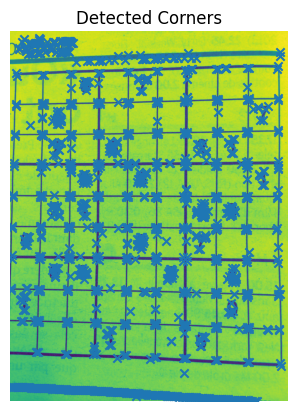

In [5]:
corners = corner_peaks(response, threshold_rel=0.01)
# Display detected corners
plt.imshow(image)
plt.scatter(corners[:,1], corners[:,0], marker='x')
plt.axis('off')
plt.title('Detected Corners')

In [6]:
sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

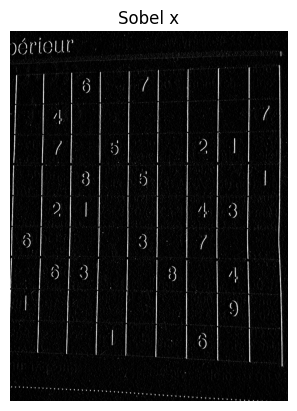

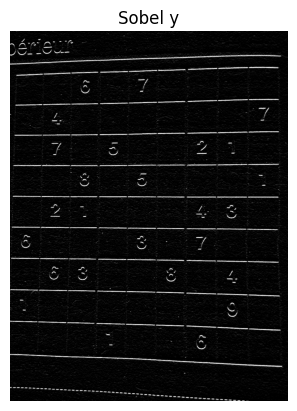

In [7]:
image_sobel_x = linear_filter(image, sobel_x_kernel)
image_sobel_y = linear_filter(image, sobel_y_kernel)
display_image_grayscale(image_sobel_x, "Sobel x")
display_image_grayscale(image_sobel_y, "Sobel y")

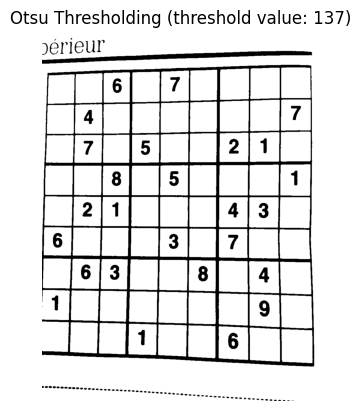

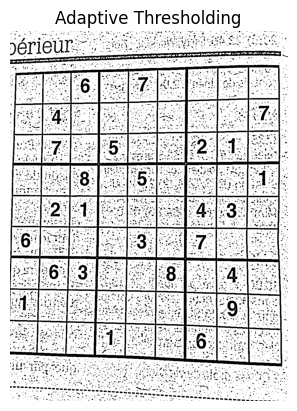

In [8]:
(hist, bin) = create_histogram(gaussian_image, 256, is_normalized=False)
threshold_val = find_otsu_threshold(hist)
image_thresh = perform_global_threshold(gaussian_image, threshold_val)
display_image_grayscale(image_thresh, f"Otsu Thresholding (threshold value: {threshold_val})")
display_image_grayscale(apply_adaptive_threshold(gaussian_image, 11, 1), "Adaptive Thresholding")

## Preprocessing and Perspective Transform

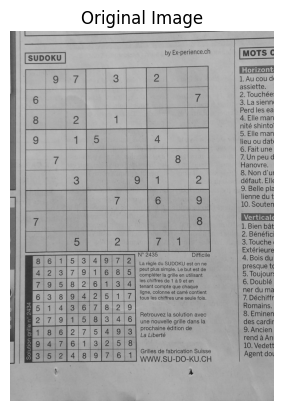

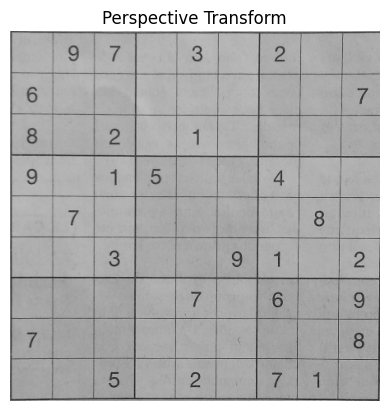

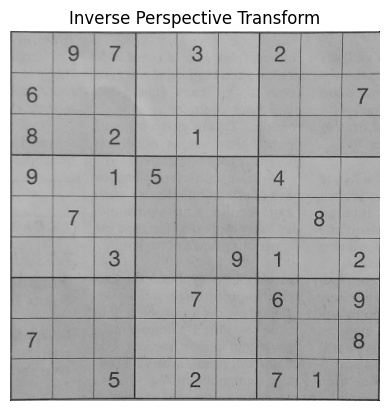

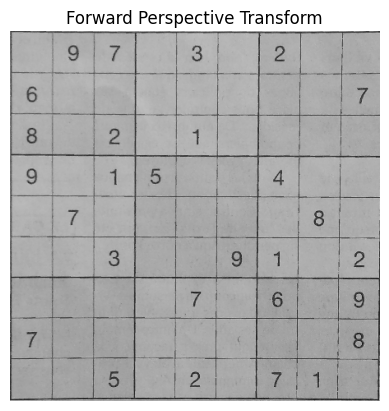

In [43]:
# Replace with image path
image_path = "data/sudoku_dataset/original/image1053.original.jpg" 
# image_path = "images/image1031.jpg"

# Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
display_image_grayscale(img, "Original Image")
if img is None:
    raise ValueError("Image not found. Check the path.")

original = img.copy()

# Pre-process: Blur and Adaptive Thresholding
# Gaussian blur reduces high-frequency noise
gaussian_kernel = create_gaussian_kernel(9, 1.6)
blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

# Thresholding
thresh = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)

# Find contours (I don't think we can build custom version)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

# Assume the Sudoku board is the largest contour by area
# largest_contour = max(contours, key=cv2.contourArea) # replace this with find_area function

contours = sorted(contours, key=cv2.contourArea, reverse=True)

grid_contour = None
for contour in contours[:5]:
    contour = contour[:,0,:]
    perimeter = find_arc_length(contour, is_closed=True)
    epsilon = 0.02 * perimeter
    approx = approximate_polygon(contour, epsilon, is_closed=True)
    if len(approx) == 4:
        grid_contour = approx
        break

if grid_contour is None:
    raise ValueError("Could not find 4 corners of the Sudoku board. Try better lighting.")


# Perspective Transform (Flatten the board)
rect = order_points(grid_contour)

# Create a perfect square image to map the board to (450x450 is easily divisible by 9)
side_length = 450
dst = np.array([
    [0, 0],
    [side_length - 1, 0],
    [side_length - 1, side_length - 1],
    [0, side_length - 1]
], dtype="float32")

# Calculate the homography matrix and apply it
matrix = cv2.getPerspectiveTransform(rect, dst)

# added logic t pick and choose the warp function and which one to use overall
board_img = cv2.warpPerspective(original, matrix, (side_length, side_length))
board_img_custom_inverse = warp_perspective_inverse(original, matrix, (side_length, side_length))
board_img_custom_forward = warp_perspective_forward(original, matrix, (side_length, side_length))
display_image_grayscale(board_img, "Perspective Transform")
display_image_grayscale(board_img_custom_inverse, "Inverse Perspective Transform")
display_image_grayscale(board_img_custom_forward, "Forward Perspective Transform")

# select the warp transform to use for the rest of the pipeline
board_img = board_img_custom_inverse


## Orientation Invariance
Applies decision function to the extracted sudoku cells at four different 90 degree orientations. The best model score is found and used to find the correct orientation.

In [44]:
import joblib

from utils import normalize_cell, extract_features

model = joblib.load("models/digit_model.pkl")

rotation_scores = {}
for angle in [0, 90, 180, 270]:
    rotated = rotate_board(board_img, angle)
    cells = extract_sudoku_cells(rotated)
    non_empty = [c[0] for c in cells if not c[1]]
    if len(non_empty) == 0:
        continue
    confidences = [model.decision_function(extract_features([normalize_cell(c)]))[0].max() for c in non_empty]
    avg_confidence = np.mean(confidences)
    print(f"angle: {angle} degrees\t score: {avg_confidence}")
    rotation_scores[angle] = avg_confidence
        
rotation_scores = dict(sorted(rotation_scores.items(), key=lambda item: item[1], reverse=True))
print(rotation_scores)

angle: 0 degrees	 score: 8.302842968047175
angle: 90 degrees	 score: 8.144327525560271
angle: 180 degrees	 score: 8.284445871001573
angle: 270 degrees	 score: 8.192075737050322
{0: np.float64(8.302842968047175), 180: np.float64(8.284445871001573), 270: np.float64(8.192075737050322), 90: np.float64(8.144327525560271)}


## Digit Recognition

Load the trained SVM model and classify each non-empty cell extracted above.

Checking 0 degrees with score: 8.302842968047175
. 9 7 | . 3 . | 2 . . 
6 . . | . . . | . . 7 
8 . 2 | . . . | . . . 
------+-------+------
9 . . | 5 . . | 4 . . 
. 7 . | . . . | . 8 . 
. . 3 | . . 9 | 1 . 2 
------+-------+------
. . . | . 7 . | 6 . 9 
7 . . | . . . | . . 8 
. . 5 | . 2 . | 7 1 . 
0 degrees is valid


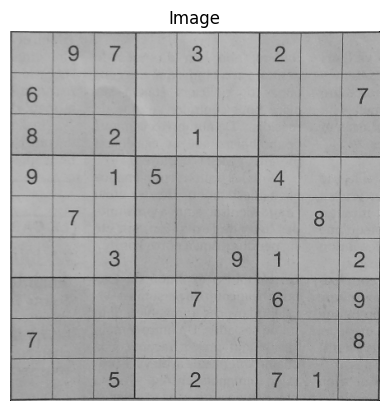

Unsolved board:
. 9 7 | . 3 . | 2 . . 
6 . . | . . . | . . 7 
8 . 2 | . . . | . . . 
------+-------+------
9 . . | 5 . . | 4 . . 
. 7 . | . . . | . 8 . 
. . 3 | . . 9 | 1 . 2 
------+-------+------
. . . | . 7 . | 6 . 9 
7 . . | . . . | . . 8 
. . 5 | . 2 . | 7 1 . 

Solved board:
1 9 7 | 4 3 8 | 2 5 6 
6 3 4 | 2 5 1 | 8 9 7 
8 5 2 | 6 9 7 | 3 4 1 
------+-------+------
9 1 8 | 5 6 2 | 4 7 3 
2 7 6 | 1 4 3 | 9 8 5 
5 4 3 | 7 8 9 | 1 6 2 
------+-------+------
4 2 1 | 8 7 5 | 6 3 9 
7 6 9 | 3 1 4 | 5 2 8 
3 8 5 | 9 2 6 | 7 1 4 


In [45]:
def recognize_digits(cells):
    board = []
    for i in range(9):
        row = []
        for j in range(9):
            cell_img, is_empty = cells[i * 9 + j]
            if is_empty:
                row.append(".")
            else:
                cell_normalized = normalize_cell(cell_img)
                features = extract_features([cell_normalized])
                digit = model.predict(features)[0]
                row.append(str(digit))
        board.append(row)
    return board

for angle, score in rotation_scores.items():
    final_board_img = rotate_board(board_img, angle)
    final_cells = extract_sudoku_cells(final_board_img)
    board = recognize_digits(final_cells)
    print(f"Checking {angle} degrees with score: {score}")
    display_board(board)
    if is_valid_sudoku(board):
        print(f"{angle} degrees is valid")
        break

if not is_valid_sudoku(board):
    raise ValueError("Invalid board — digit recognition may have errors or the board is impossible to solve.")

display_image_grayscale(final_board_img)
print("Unsolved board:")
display_board(board)
solve_sudoku(board)
print()
print("Solved board:")
display_board(board)